<a href="https://colab.research.google.com/github/burakayy7/deep_learning_bifurcation_prediction_collection_V1/blob/main/ews_data_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Dependencies
!pip install ewstools==2.1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.7
    Uninstalling dill-0.3.7:
      Successfully uninstalled dill-0.3.7
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.15
    Uninstalling multiprocess-0.70.15:
      Success

In [ ]:
import numpy as np
import scipy.integrate
import random

import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint

import pandas as pd

import os
from google.colab import files

# Testing (non-important)

In [ ]:
import numpy as np
import scipy.integrate
import random

def generate_dynamical_system():
    """
    Generates a random two-dimensional dynamical system based on given equations.
    """
    # Define polynomial terms up to third order
    def polynomial_terms(x, y):
        return np.array([1, x, y, x**2, x*y, y**2, x**3, (x**2)*y, x*(y**2), y**3])

    # Randomly sample ai and bi from N(0,1)
    a = np.random.normal(0, 1, 10)
    b = np.random.normal(0, 1, 10)

    # Set half of them randomly to zero
    zero_indices = np.random.choice(10, 5, replace=False)
    a[zero_indices] = 0
    b[zero_indices] = 0

    # Ensure cubic terms have negative absolute values
    for i in range(6, 10):  # Indices of cubic terms
        a[i] = -abs(a[i])
        b[i] = -abs(b[i])

    # Define the system of ODEs
    def system(state, t):
        x, y = state
        p = polynomial_terms(x, y)
        dxdt = np.dot(a, p)
        dydt = np.dot(b, p)
        return [dxdt, dydt]

    return system

def simulate_system(system, initial_conditions, t_range):
    """
    Simulates the system using numerical integration.
    """
    return scipy.integrate.odeint(system, initial_conditions, t_range)

def generate_dataset(num_samples=1, t_range=np.linspace(0, 10, 100)):
    """
    Generates a dataset of simulated dynamical systems.
    """
    dataset = []
    for _ in range(num_samples):
        system = generate_dynamical_system()
        initial_conditions = np.random.uniform(-1, 1, 2)  # Random initial state
        trajectory = simulate_system(system, initial_conditions, t_range)
        dataset.append(trajectory)
    return np.array(dataset)

# Example usage
data = generate_dataset()
print("Generated dataset shape:", data.shape)


Generated dataset shape: (1, 100, 2)


<ipython-input-1-289a47e5da28>:41: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return scipy.integrate.odeint(system, initial_conditions, t_range)


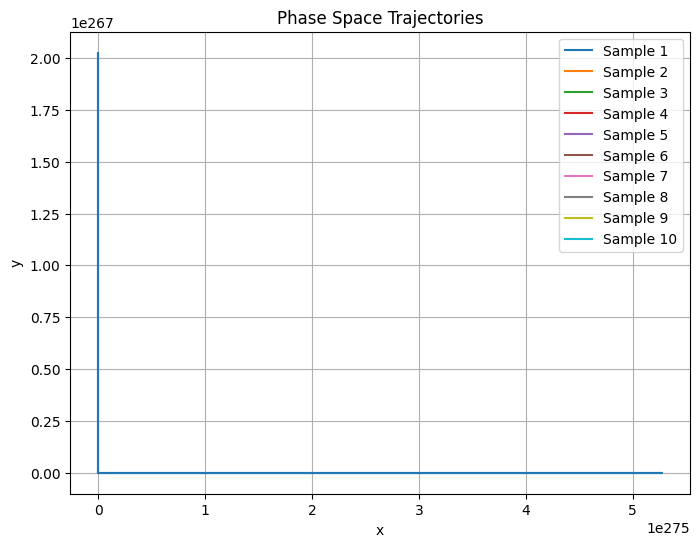

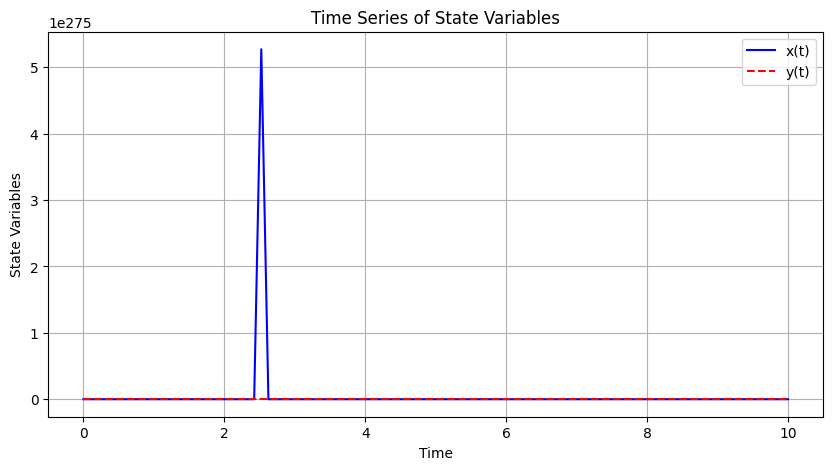

In [ ]:
import matplotlib.pyplot as plt

def plot_phase_space(data):
    """Plots phase space (x vs y) for a few sample trajectories."""
    plt.figure(figsize=(8, 6))

    for i in range(min(10, len(data))):  # Plot up to 10 sample trajectories
        plt.plot(data[i][:, 0], data[i][:, 1], label=f"Sample {i+1}")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Phase Space Trajectories")
    plt.legend()
    plt.grid()
    plt.show()

def plot_time_series(data, t_range):
    """Plots time series of x and y for a sample trajectory."""
    plt.figure(figsize=(10, 5))

    sample = data[0]  # Select the first trajectory
    plt.plot(t_range, sample[:, 0], label="x(t)", color="b")
    plt.plot(t_range, sample[:, 1], label="y(t)", color="r", linestyle="dashed")

    plt.xlabel("Time")
    plt.ylabel("State Variables")
    plt.title("Time Series of State Variables")
    plt.legend()
    plt.grid()
    plt.show()

# Generate dataset
t_range = np.linspace(0, 10, 100)
data = generate_dataset(num_samples=10, t_range=t_range)

# Visualize the results
plot_phase_space(data)
plot_time_series(data, t_range)

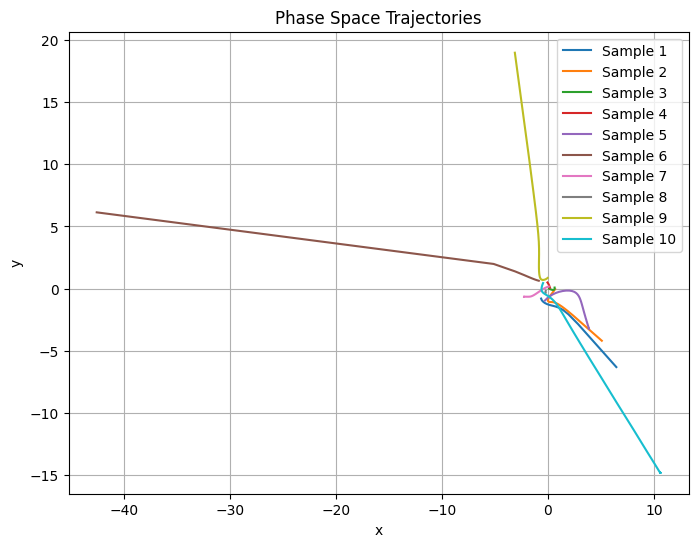

ValueError: x and y must have same first dimension, but have shapes (100,) and (14,)

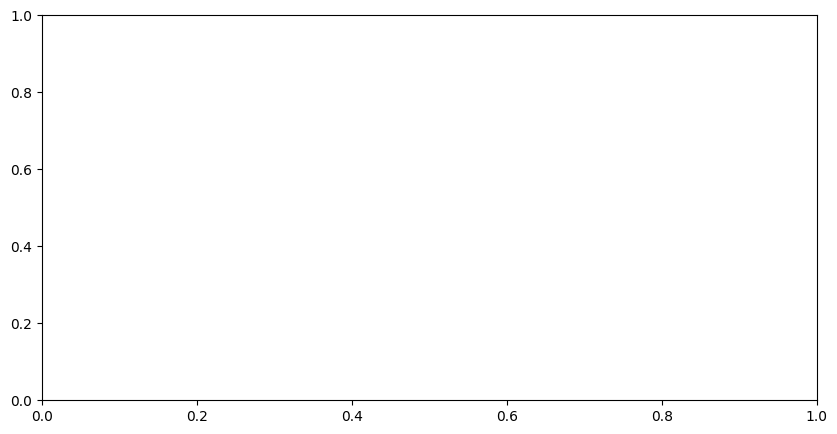

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the polynomial basis up to the third order
def polynomial_terms(x, y):
    return np.array([1, x, y, x**2, x*y, y**2, x**3, (x**2)*y, x*(y**2), y**3])

# Generate random parameters
def generate_parameters():
    a = np.random.normal(0, 1, 10)  # Sample from normal distribution
    b = np.random.normal(0, 1, 10)

    # Set half of the parameters to zero randomly
    zero_indices = np.random.choice(10, 5, replace=False)
    a[zero_indices] = 0
    b[zero_indices] = 0

    # Ensure cubic terms are negative for bounded solutions
    for i in range(6, 10):
        a[i] = -abs(a[i])
        b[i] = -abs(b[i])

    return a, b

# Define the dynamical system
def dynamical_system(t, state, a, b):
    x, y = state
    p = polynomial_terms(x, y)
    dxdt = np.dot(a, p)
    dydt = np.dot(b, p)
    return [dxdt, dydt]

# Simulate a single trajectory
def simulate_trajectory(t_range):
    a, b = generate_parameters()
    initial_conditions = np.random.uniform(-1, 1, 2)  # Random initial state
    sol = solve_ivp(dynamical_system, [t_range[0], t_range[-1]], initial_conditions,
                    t_eval=t_range, args=(a, b), method='RK45')
    return sol.y.T  # Transpose so that shape is (time_steps, 2)

# Generate multiple datasets
def generate_dataset(num_samples=1, t_range=np.linspace(0, 10, 100)):
    return [simulate_trajectory(t_range) for _ in range(num_samples)]

# Visualization functions
def plot_phase_space(data):
    """Plot phase space (x vs y)"""
    plt.figure(figsize=(8, 6))
    for i in range(min(10, len(data))):
        plt.plot(data[i][:, 0], data[i][:, 1], label=f"Sample {i+1}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Phase Space Trajectories")
    plt.legend()
    plt.grid()
    plt.show()

def plot_time_series(data, t_range):
    """Plot time series of x and y"""
    plt.figure(figsize=(10, 5))
    sample = data[0]  # Select first trajectory
    plt.plot(t_range, sample[:, 0], label="x(t)", color="b")
    plt.plot(t_range, sample[:, 1], label="y(t)", color="r", linestyle="dashed")
    plt.xlabel("Time")
    plt.ylabel("State Variables")
    plt.title("Time Series of State Variables")
    plt.legend()
    plt.grid()
    plt.show()

# Run the simulation
t_range = np.linspace(0, 10, 100)
data = generate_dataset(num_samples=10, t_range=t_range)

# Plot the results
plot_phase_space(data)
plot_time_series(data, t_range)


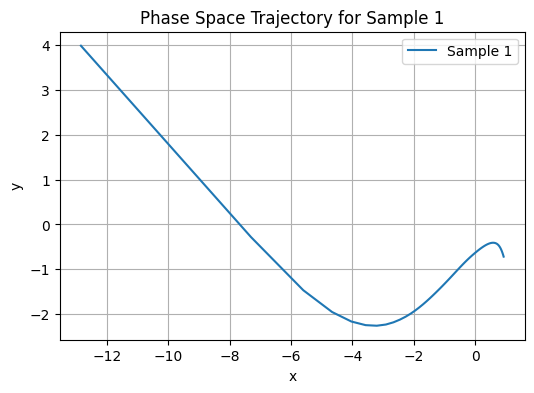

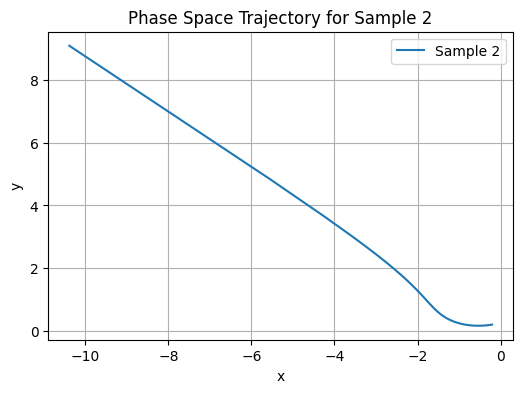

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define polynomial basis up to third order
def polynomial_basis(x, y):
    return np.array([1, x, y, x**2, x*y, y**2, x**3, x**2*y, x*y**2, y**3])

# Define the dynamical system
def dynamical_system(t, state, a, b):
    x, y = state
    p = polynomial_basis(x, y)
    dxdt = np.dot(a, p)
    dydt = np.dot(b, p)
    return [dxdt, dydt]

# Simulation parameters
num_samples = 2  # Number of separate simulations
t_range = np.linspace(0, 10, 500)  # Time range

for i in range(num_samples):
    # Randomly generate coefficients from normal distribution
    a = np.random.normal(0, 1, 10)
    b = np.random.normal(0, 1, 10)

    # Set half of them to zero randomly
    zero_indices = np.random.choice(10, 5, replace=False)
    a[zero_indices] = 0
    b[zero_indices] = 0

    # Make cubic terms negative for bounded solutions
    a[-3:] = -np.abs(a[-3:])
    b[-3:] = -np.abs(b[-3:])

    # Solve the system
    initial_state = np.random.uniform(-1, 1, 2)  # Random initial condition (x0, y0)
    sol = solve_ivp(dynamical_system, [t_range[0], t_range[-1]], initial_state, t_eval=t_range, args=(a, b))

    # Plot each sample in a separate figure
    plt.figure(figsize=(6, 4))
    plt.plot(sol.y[0], sol.y[1], label=f"Sample {i+1}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.title(f"Phase Space Trajectory for Sample {i+1}")
    plt.grid()

plt.show()


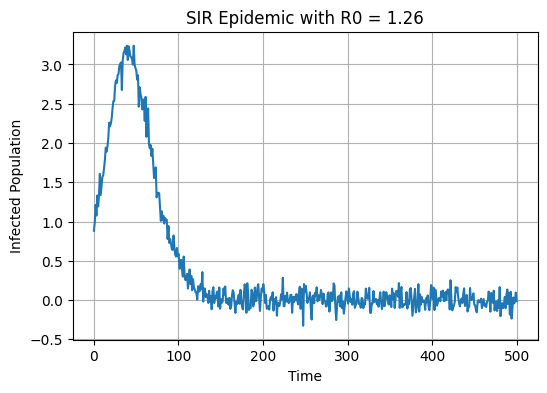

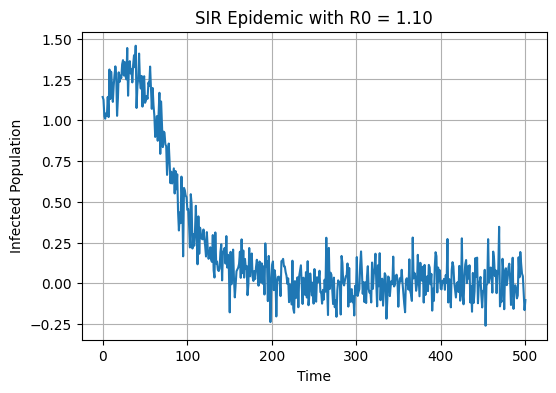

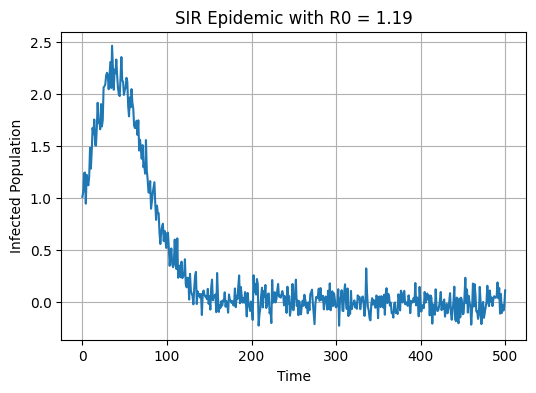

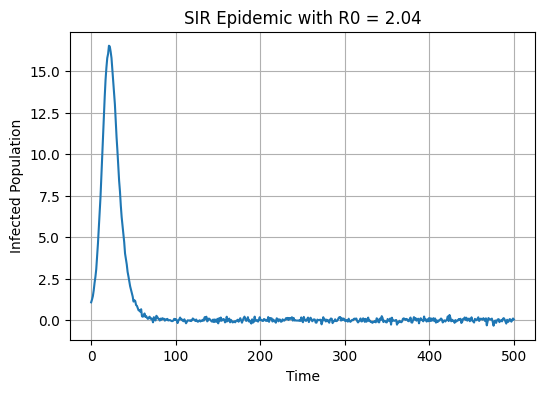

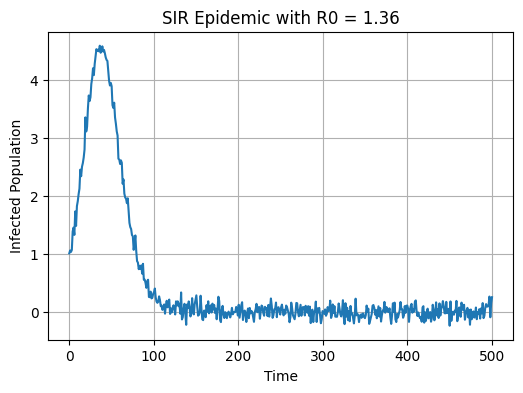

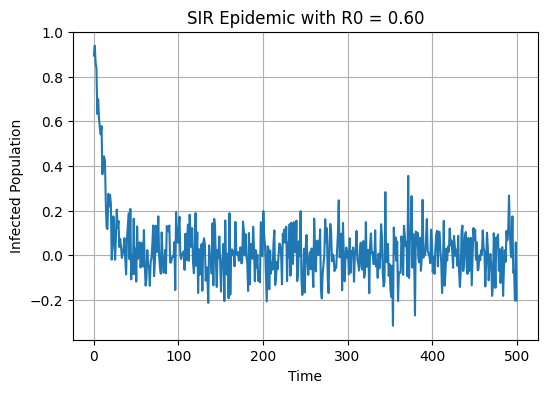

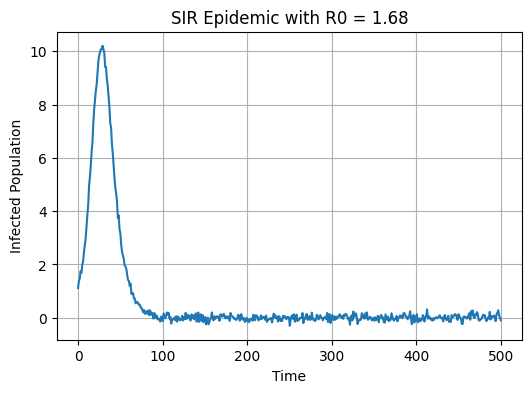

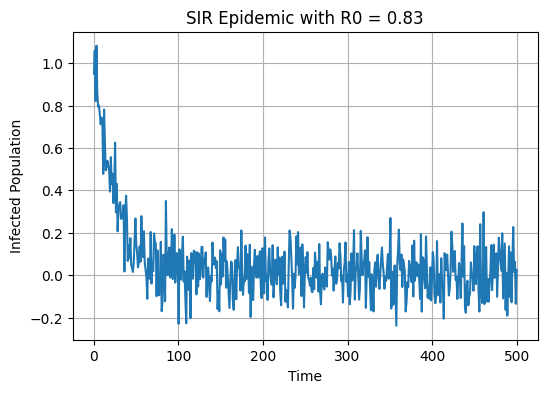

In [ ]:
def epidemic_system(t, state, beta, gamma):
    S, I, R = state
    N = S + I + R  # Total population
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# # Simulation parameters
# num_samples = 6
# t_range = np.linspace(0, 100, 500)  # Longer time range for epidemic simulation

# for i in range(num_samples):
#     # Randomly generate beta and gamma
#     beta = np.random.uniform(0.1, 0.5)  # Example range for infection rate
#     gamma = np.random.uniform(0.05, 0.2)  # Example range for recovery rate

#     # Solve the system
#     initial_state = [99, 1, 0]  # Initial condition (S0, I0, R0) - e.g., 1 infected in 100
#     sol = solve_ivp(epidemic_system, [t_range[0], t_range[-1]], initial_state, t_eval=t_range, args=(beta, gamma))

#     # Plot each sample
#     plt.figure(figsize=(6, 4))
#     plt.plot(t_range, sol.y[0], label="Susceptible")
#     plt.plot(t_range, sol.y[1], label="Infected")
#     plt.plot(t_range, sol.y[2], label="Recovered")
#     plt.xlabel("Time")
#     plt.ylabel("Population")
#     plt.legend()
#     plt.title(f"SIR Epidemic Simulation {i+1}")
#     plt.grid()

# plt.show()


def add_white_noise(data, noise_level=0.5):
    """Adds Gaussian white noise to the data.

    Args:
        data: The original data.
        noise_level: The standard deviation of the noise.

    Returns:
        The data with added noise.
    """
    noise = np.random.normal(scale=noise_level, size=data.shape)
    noisy_data = data + noise
    return noisy_data


# Simulation parameters
num_samples = 8
t_range = np.linspace(0, 500, 500)
gamma = 0.2  # Fixed recovery rate

for i in range(num_samples):
    # Vary beta to control R0
    # beta = (i + 1) * gamma  # R0 will vary from 1 to 6
    beta = np.random.uniform(0.1, 0.5)  # Example range for infection rate
    # Solve the system
    initial_state = [99, 1, 0]
    sol = solve_ivp(epidemic_system, [t_range[0], t_range[-1]], initial_state, t_eval=t_range, args=(beta, gamma))
    sol.y = add_white_noise(sol.y, noise_level=0.1)  # Adjust noise_level as needed
    # Plot each sample
    plt.figure(figsize=(6, 4))
    plt.plot(t_range, sol.y[1], label="Infected")  # Plot only Infected population
    plt.xlabel("Time")
    plt.ylabel("Infected Population")
    plt.title(f"SIR Epidemic with R0 = {beta/gamma:.2f}")
    plt.grid()

plt.show()

# V2 Testing

In [ ]:


# Define polynomial basis up to third order
def polynomial_basis(x, y):
    return np.array([1, x, y, x**2, x*y, y**2, x**3, x**2*y, x*y**2, y**3])

# Define the dynamical system
def dynamical_system(t, state, a, b):
    x, y = state
    p = polynomial_basis(x, y)
    dxdt = np.dot(a, p)
    dydt = np.dot(b, p)
    return [dxdt, dydt]
def epidemic_system(t, state, beta, gamma):
    S, I, R = state
    N = S + I + R  # Total population
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]
def add_white_noise(data, noise_level=0.5):
    """Adds Gaussian white noise to the data.

    Args:
        data: The original data.
        noise_level: The standard deviation of the noise.

    Returns:
        The data with added noise.
    """
    noise = np.random.normal(scale=noise_level, size=data.shape)
    noisy_data = data + noise
    return noisy_data

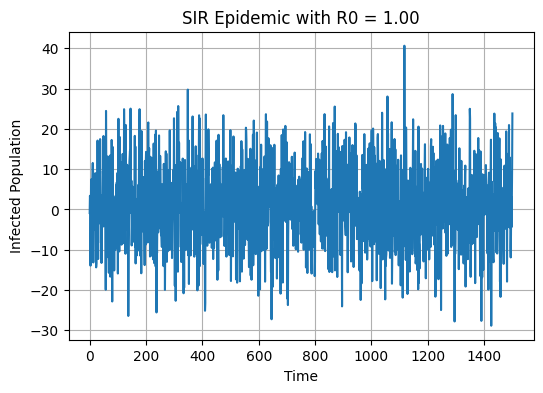

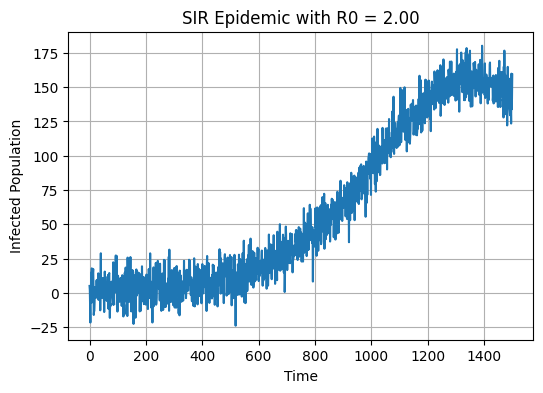

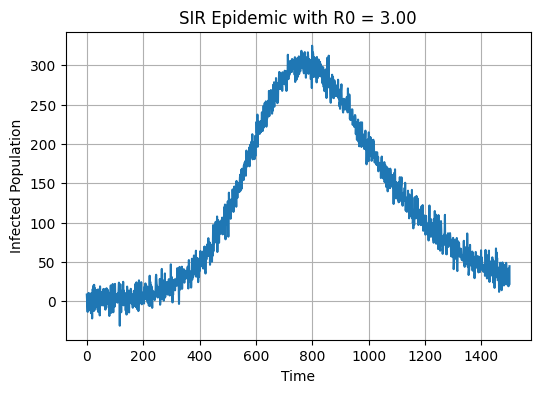

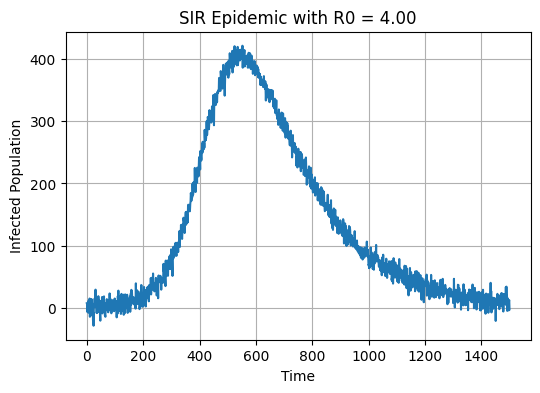

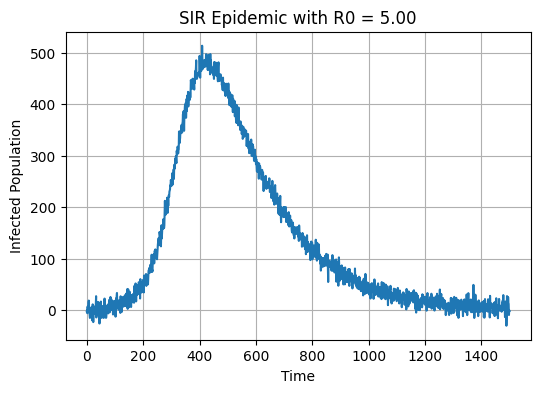

In [ ]:



# Simulation parameters
num_samples = 5
t_range = np.linspace(0, 1500, 1500)
gamma = 0.005  # Fixed recovery rate

sol_array = []

for i in range(num_samples):
    # Vary beta to control R0
    beta = (i + 1) * gamma  # R0 will vary from 1 to 6
    # beta = gamma + 0.01 # the disease dies down
    # beta = np.random.uniform(0.001, 0.1)  # Example range for infection rate
    # Solve the system
    initial_state = [999, 1, 0] # initial susceptible, infected, and recovered respectifully
    sol = solve_ivp(epidemic_system, [t_range[0], t_range[-1]], initial_state, t_eval=t_range, args=(beta, gamma))

    sol.y = add_white_noise(sol.y, noise_level=10)  # Adjust noise_level as needed
    sol_array.append(sol.y[1])
    # Plot each sample
    plt.figure(figsize=(6, 4))
    plt.plot(t_range, sol.y[1], label="Infected")  # Plot only Infected population
    plt.xlabel("Time")
    plt.ylabel("Infected Population")
    plt.title(f"SIR Epidemic with R0 = {beta/gamma:.2f}")
    plt.grid()

plt.show()

# Test for a Bifurcation using EWSTOOLS

In [ ]:
!pip install ewstools==2.1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
import ewstools


In [ ]:
sims = pd.DataFrame(sol.y[1], columns=['infected'])
sims = sims.set_index(t_range)
sims = sims.reset_index(drop=True)

In [ ]:
ts = ewstools.TimeSeries(data=sims['infected'], transition=800)

ts.detrend(method='Lowess', span=0.2)

{'variance': -0.2997053637072211,
 'cv': -0.4836070557929476,
 'std': -0.2997053637072211,
 'ac1': -0.08646165582279812,
 'ac4': -0.2028568111840178,
 'skew': 0.017506813118777675}

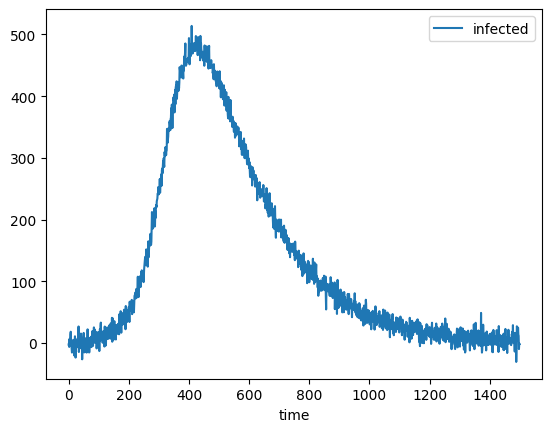

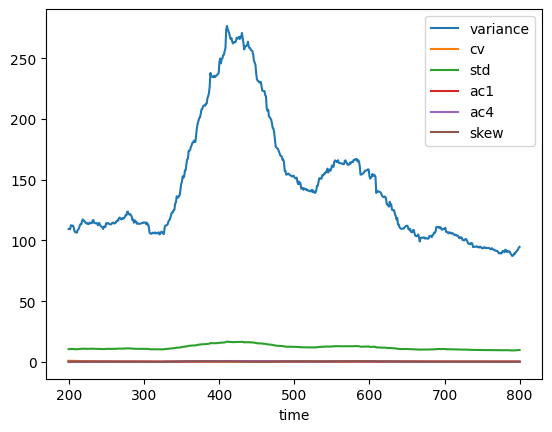

In [ ]:
rw = .25

ts.compute_var(rolling_window=rw)
ts.compute_cv(rolling_window=rw)
ts.compute_std(rolling_window=rw)
ts.compute_auto(rolling_window=rw, lag=1)
ts.compute_auto(rolling_window=rw, lag=4)
ts.compute_skew(rolling_window=rw)
sims.plot()
ts.ews.dropna().plot()

ts.compute_ktau()
ts.ktau

# Testing V3 but with odeint instead of solve_ivp

In [ ]:
!pip install PyCoBi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.1/739.1 kB 20.3 MB/s eta 0:00:00


System converged to equilibrium.


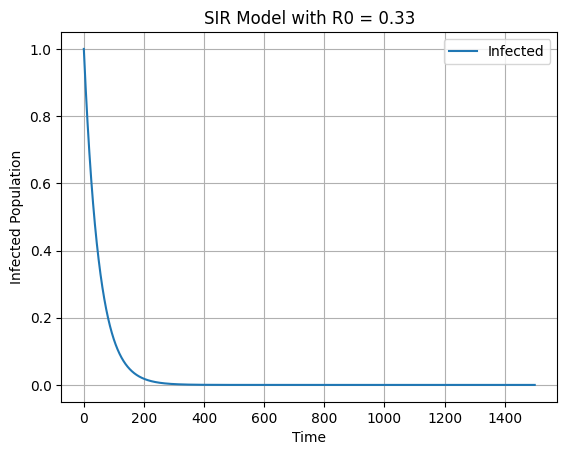

In [ ]:
# Define the epidemic system
def epidemic_system(state, t, beta, gamma):
    S, I, R = state
    N = S + I + R  # Total population
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Check if the system converges (last 10 points should be close)
def has_converged(sol, threshold=1e-6):
    return np.max(np.abs(np.diff(sol[-10:]))) < threshold

# Parameters
gamma = 0.03  # Fixed recovery rate
beta = 0.01  # You can vary this to explore bifurcations
initial_state = [999, 1, 0]  # Initial S, I, R

# Time range: 10,000 steps with small dt
t_range = np.linspace(0, 1500, 10000)

# Solve the system
sol = odeint(epidemic_system, initial_state, t_range, args=(beta, gamma))
I_values = sol[:, 1]  # Extract the infected population

# Check for convergence
if has_converged(I_values):
    print("System converged to equilibrium.")
else:
    print("System did NOT converge!")

# Plot the results
plt.plot(t_range, I_values, label="Infected")
plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title(f"SIR Model with R0 = {beta/gamma:.2f}")
plt.grid()
plt.legend()
plt.show()

In [ ]:
dsf_content = """# SIR model
@parameters beta gamma
@variables S I R
@functions dS dI dR
@equations
dS = -beta * S * I / (S + I + R)
dI = beta * S * I / (S + I + R) - gamma * I
dR = gamma * I"""

# Set the file name
file_name = "sir_model.dsf"

# Write the content to the file
with open(file_name, 'w') as f:
    f.write(dsf_content)

# Confirm the file was created
print(f"File '{file_name}' has been created.")

File 'sir_model.dsf' has been created.


In [ ]:
# Bifurcation Analysis
import pycobi
from pycobi import ODESystem

ode_sys = ODESystem("/content/sir_model.dsf")

ode_sys.add_parameter("beta", beta-0.005, beta+0.001)#0.01, 0.5)  # Vary beta from 0.01 to 0.5
ode_sys.add_parameter("gamma", gamma) #0.005)

# Find equilibrium points
equilibria = ode_sys.find_equilibria()
print("Equilibrium points:", equilibria)


ValueError: Auto-07p directory has not been set as environment variable. Please provide path to cmds/auto.env.sh or set environment variable yourself.

# pydstool installation stuff |  PyDSTool alternatives: PyCoBi which is auto-7p based

or PyRates

In [ ]:

!apt-get update
!apt-get install -qq gfortran
!apt-get install -qq python3-numpy
!apt-get install -qq python3-scipy

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,318 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,659 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jamm

In [ ]:
!apt-get install -qq swig

Selecting previously unselected package swig4.0.
(Reading database ... 129367 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu1_all.deb ...
Unpacking swig (4.0.2-1ubuntu1) ...
Setting up swig4.0 (4.0.2-1ubuntu1) ...
Setting up swig (4.0.2-1ubuntu1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!pip install PyDSTool

In [ ]:
import PyDSTool as dst

ImportError: cannot import name 'int' from 'numpy' (/usr/local/lib/python3.11/dist-packages/numpy/__init__.py)

In [ ]:
!apt-get update
!apt-get install -qq gfortran
!apt-get install -qq python3-numpy
!apt-get install -qq python3-scipy
!apt-get install -qq swig

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,662 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,707 kB]
Fetched 11.4 MB in 3s (4,108 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/So

In [ ]:
!pip install PyCoBi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.1/739.1 kB 39.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.23.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.23.5 which is incompatible.
chex 0.1.88 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.4 requires numpy>=1.24.4, but you have numpy 1.23.5 which is 

In [ ]:
import pycobi

# Simulating the models using "null" and "forced" stochastic simulations via the Euler Maruyama method

In [ ]:
def euler_maruyama(system, initial_state, t_range, params, noise_level=0.01):
    """Simulates the system using the Euler-Maruyama method."""
    dt = t_range[1] - t_range[0]  # Step size
    num_steps = len(t_range)
    state = np.zeros((num_steps, len(initial_state)))
    state[0] = initial_state

    for i in range(1, num_steps):
        # Draw noise from triangular distribution
        noise = np.random.triangular(0.0075, 0.01, 0.0125)
        # Assuming dominant_eigenvalue is pre-calculated or estimated
        noise *= dominant_eigenvalue

        # Euler-Maruyama step
        state[i] = state[i - 1] + dt * np.array(system(state[i - 1], t_range[i - 1], *params)) + noise * np.sqrt(dt)

    return state

# using Chakraborty data generation

In [ ]:
!git clone https://github.com/AmitKChakraborty/EWSofInfectiousDiseases.git
!pip install seaborn
# !pip install ewstools

Cloning into 'EWSofInfectiousDiseases'...
remote: Enumerating objects: 1340, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 1340 (delta 148), reused 155 (delta 83), pack-reused 1069 (from 1)
Receiving objects: 100% (1340/1340), 44.77 MiB | 6.34 MiB/s, done.
Resolving deltas: 100% (393/393), done.
Updating files: 100% (921/921), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!python /content/EWSofInfectiousDiseases/Training_Data_Generation/SIR_model_WhiteNoise_training_data.py

0.02
[0.00410967 0.00657329 0.00048704 0.00672114 0.00451275 0.00186338
 0.00337447 0.00515181 0.00346835 0.00896323]
[4.944599928129859e-06, 2.84438735765708e-06, 1.9664742404613952e-06, 1.7733155711869254e-06, 5.599384933834988e-06, 1.4410497330506073e-05, 1.7840072347771578e-05, 1.2023200233286987e-05, 1.3446524788265906e-05, 9.108587956145969e-06]

Begin simulations 

[1500.    0.    0.    0.    0.    0.    0.    0.    0.    0.]
Simulation 1 complete
[1500. 1500.    0.    0.    0.    0.    0.    0.    0.    0.]
Simulation 2 complete
[1500. 1500. 1500.    0.    0.    0.    0.    0.    0.    0.]
Simulation 3 complete
[1500. 1500. 1500. 1500.    0.    0.    0.    0.    0.    0.]
Simulation 4 complete
[1500. 1500. 1500. 1500. 1500.    0.    0.    0.    0.    0.]
Simulation 5 complete
[1500.   1500.   1500.   1500.   1500.   1258.58    0.      0.      0.
    0.  ]
Simulation 6 complete
[1500.   1500.   1500.   1500.   1500.   1258.58  931.94    0.      0.
    0.  ]
Simulation 7 complete

In [ ]:
# for the input data, you first have to detrend using Lowess (0.2) = residual time series, then normalize it by dividing by
# the average of the entire time series
'''
Apply Noise-induced SIR model data trained DL algorithm to test models
Edited from published codes by Bury et al. (2021), Deep learning for early warning signals of tipping points, PNAS.

'''

#python libraries
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import gc
import numpy as np
import pandas as pd
import random
import sys
import itertools
import tensorflow as tf
from tensorflow.keras.models import load_model
from datetime import datetime


random.seed(datetime.now())

classifier_length = 500                                   #classifier_length are 100 and 500
type = 'forced'                                            #types are 'forced' and 'null'
test_model = 'SIRwhiteN'                                    #test_models are 'SIRwhiteN', 'SIRenvN', 'SIRdemN', 'SEIR', 'COVID'
NoOFSim = 10                                                #Number of simulation for each type; 7 for COVID, 10 for others


if not os.path.exists('/content/EWSofInfectiousDiseases/Trained_DL_models_and_testing/data/ml_pred_SIR_CL{}'.format(classifier_length)):
    os.makedirs('../data/ml_pred_SIR_CL{}'.format(classifier_length))

if not os.path.exists('/content/predictions'):
    os.makedirs('/content/predictions')

for simulation in np.arange(1, NoOFSim+1):

    # Filepath to residual time series to make predictions on
    filepath = '../data/resids/resids_{}_{}{}.csv'.format(test_model, type, simulation)

    # Filepath to export ensemble DL predictions to
    filepath_out = '../data/ml_pred_SIR_CL{}/ensemble_trend_probs_{}{}_{}_len{}.csv'.format(classifier_length, test_model, type, simulation, classifier_length)

    # Type of classifier to use (500 or 100)
    ts_len = classifier_length

    '''
    The following two parameters control how many sample points along the
    timeseries are used, and the length between them.  For instance, for an input
    time series equal to or less then length 500, mult_factor=10 and
    pad_samples=50 means that it will do the unveiling in steps of 10 datapoints,
    at 50 evenly spaced points across the entire time series (50 x 10 = 500).
    Needs to be adjusted according to whether you are using the trained 500 length
    or 100 length classifier.
    '''

    # Steps of datapoints in between each DL prediction
    mult_factor = 10

    # Total number of DL predictions to make
    pad_samples = int(classifier_length/mult_factor)

    df = pd.read_csv(filepath).dropna()
    # Length of inupt time series
    df_len = len(df)

    if df_len > ts_len:
        #df of last classifier_length=500 points
        df_last = df[-classifier_length:]
        resids = df_last['residuals'].values.reshape(1,-1,1)
        input_series = resids
        seq_len = len(df_last)
    else:
        resids = df['residuals'].values.reshape(1,-1,1)
        # Length of inupt time series
        seq_len = len(df)
        input_series = resids

    def get_dl_predictions(resids, model_type, kk):

        '''
        Generate DL prediction time series on resids
        from DL classifier with type 'model_type' and index kk.
        '''

        # Setup file to store DL predictions
        predictions_file_name = 'predictions/y_pred_{}_{}.csv'.format(kk,model_type)
        f1 = open(predictions_file_name,'w')

        # Load in specific DL classifier
        model_name = 'trained_models_Noise_Induced_SIR_CL{}/best_model_{}_{}_length{}.pkl'.format(classifier_length, kk,model_type, ts_len)
        model = load_model(model_name)

        # Loop through each possible length of padding
        # Start with revelaing the DL algorith only the earliest points
        for pad_count in range(pad_samples-1, -1, -1):

            temp_ts = np.zeros((1,ts_len,1))

            ts_gap = ts_len-seq_len
            pad_length = mult_factor*pad_count

            if pad_length + ts_gap > ts_len:
                zero_range = ts_len
            else:
                zero_range = pad_length + ts_gap

            if zero_range == ts_len:
                # Set all ML predictions to zero
                y_pred = np.zeros(2).reshape(1,2)
            else:
                for j in range(0, zero_range):
                    temp_ts[0,j] = 0
                for j in range(zero_range, ts_len):
                    temp_ts[0,j] = resids[0,j-zero_range]

                # normalizing inputs: take averages, since the models were also trained on averaged data.
                values_avg = 0.0
                count_avg = 0
                for j in range (0,ts_len):
                    if temp_ts[0,j] != 0:
                        values_avg = values_avg + abs(temp_ts[0,j])
                        count_avg = count_avg + 1
                if count_avg != 0:
                    values_avg = values_avg/count_avg
                for j in range (0,ts_len):
                    if temp_ts[0,j] != 0:
                        temp_ts[0,j] = temp_ts[0,j]/values_avg

                # Compute DL prediction
                y_pred = model.predict(temp_ts)



            # Write predictions to file
            np.savetxt(f1, y_pred, delimiter=',')
            print('Predictions computed for padding={}'.format(pad_count*mult_factor))

        # Delete model and do garbage collection to free up RAM
        tf.keras.backend.clear_session()
        if zero_range != ts_len:
            del model
        gc.collect()
        f1.close()

        return



    # Compute DL predictions from all 20 trained models
    for model_type in [1,2]:
        for kk in np.arange(1,2):
            print('Compute DL predictions for model_type={}, kk={}'.format(
                model_type,kk))

            get_dl_predictions(resids, model_type, kk)




    # Compute average prediction among all 20 DL classifiers
    list_df_preds = []
    for model_type in [1,2]:
        for kk in np.arange(1,2):
            filename = 'predictions/y_pred_{}_{}.csv'.format(kk,model_type)
            df_preds = pd.read_csv(filename,header=None)
            df_preds['time_index'] = df_preds.index
            df_preds['model_type'] = model_type
            df_preds['kk'] = kk
            list_df_preds.append(df_preds)


    # Concatenate
    df_preds_all = pd.concat(list_df_preds).reset_index(drop=True)

    # Compute mean over all predictions
    df_preds_mean = df_preds_all.groupby('time_index').mean()
    df_preds_mean = df_preds_mean[[0,1]]
    df_preds_mean = df_preds_mean.assign(b=df_preds_mean.iloc[:,[1]].sum(axis=1))

    # Export predictions
    df_preds_mean.iloc[:,[0,1,2]].to_csv(filepath_out,index=False,header=False)





# Data Simulation Code (from paper github)
How R0 changes | from github:

In [ ]:
#Training data generation of SIR model with Multiplicative Environmental Noise
#Edited from published codes by Bury et al. (2021), Deep learning for early warning signals of tipping points, PNAS.
#python libraries
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ewstools
import random
import sys

#parameters
dt = 0.01
t0 = 0
tmax = 1500
tburn = 100
numSims = 10
seed = 0

dt2 = 1
rw = 0.25
span=0.2
lags = [1]
ews = ['var','ac']

# Model
def de_fun_S(S,I,Lambda,beta,mu):
  return Lambda-beta*S*I-mu*S

def de_fun_I(S,I,beta,alpha,mu):
  return beta*S*I- alpha*I-mu*I

#batches
# count = int(sys.argv[1])
count = 1

#model parameters
Lambda = 100
alpha = 1
mu = 1
S0 = 500
I0 = 7

# bifurcation point
betabif = mu*(alpha+mu)/Lambda
print(betabif)


# DataFrame for each variable
df_sims_S = pd.DataFrame([])
df_sims_I = pd.DataFrame([])

#arrays to store single time-series data
t = np.arange(t0,tmax,dt)
S = np.zeros(len(t))
I = np.zeros(len(t))


beta = np.zeros(len(t))
beta_intercept = []
beta_slope = []
tbif = np.zeros(numSims)

right_intercept = betabif/2
mid_intercept = right_intercept/2

beta_intercept = np.random.triangular(0, mid_intercept, right_intercept, numSims)

for j in range(numSims // 2):
    left_slope = 0
    right_slope = (betabif-beta_intercept[j])/1500
    mid_slope = right_slope/2
    slope = np.random.triangular(left_slope, mid_slope, right_slope)
    beta_slope.append(slope)

for j in range(numSims // 2, numSims):
    left_slope = (betabif-beta_intercept[j])/1500
    right_slope = (2*betabif-beta_intercept[j])/1500
    mid_slope = right_slope/2
    slope = np.random.triangular(left_slope, mid_slope, right_slope)
    beta_slope.append(slope)

print(beta_intercept)
print(beta_slope)

 # Initialise a list to collect trajectories
list_traj_append = []
label_list = []
tbif = np.zeros(numSims)

# loop over simulations
print('\nBegin simulations \n')
for j in range(numSims):
    # noise intensity
    sigma_S = np.random.triangular(0, 0.5, 1)
    sigma_I = np.random.triangular(0, 0.5, 1)

    beta0 = beta_intercept[j]
    beta1 = beta_slope[j]
    beta = np.zeros(len(t))

    for k in range(len(t)):
        beta[k] = beta0 + t[k]*beta1

    beta = pd.Series(beta, index=t)

    # Time at which bifurcation occurs; we set bifurcation point at 1500 for null simulations
    if betabif <= beta.iloc[len(t)-1]:
        tbif[j] = beta[beta > betabif].index[1]
    else:
        tbif[j] = 1500
    print(tbif)

    # Create brownian increments (s.d. sqrt(dt))
    dW_S_burn = np.random.normal(loc=0, scale=sigma_S*np.sqrt(dt), size = int(tburn/dt))
    dW_S = np.random.normal(loc=0, scale=sigma_S*np.sqrt(dt), size = len(t))

    dW_I_burn = np.random.normal(loc=0, scale=sigma_I*np.sqrt(dt), size = int(tburn/dt))
    dW_I = np.random.normal(loc=0, scale=sigma_I*np.sqrt(dt), size = len(t))

    # Run burn-in period
    for i in range(int(tburn/dt)):
        S0 = S0 + de_fun_S(S0,I0,Lambda,beta[0],mu)*dt + dW_S_burn[i]
        if np.isnan(S0):
            S0 = random.uniform(0, 500)
        I0 = I0 + de_fun_I(S0,I0,beta[0],alpha,mu)*dt + dW_I_burn[i]
        if np.isnan(I0):
            I0 = random.uniform(0, 0.5)

    #if intial infected less than 0.1; set random initial between (0.1, 1)
    if I0 < 0.1 :
        I0 = random.uniform(0.1 , 1)

    # Initial condition post burn-in period
    S[0]=S0
    I[0]=I0

    # Run simulation
    for i in range(len(t)-1):
        S[i+1] = S[i] + de_fun_S(S[i],I[i],Lambda,beta.iloc[i],mu)*dt + S[i]*dW_S[i]
        I[i+1] = I[i] + de_fun_I(S[i],I[i], beta.iloc[i],alpha,mu)*dt + I[i]*dW_I[i]
        # make sure that state variable remains >= 0
        if S[i+1] < 0:
            S[i+1] = 0
        if I[i+1] < 0.1:
            I[i+1] = random.uniform(0.1 , 1)
    # Store series data in a temporary DataFrame
    data = {'tsid': (j+1)*np.ones(len(t)),
                'Time': t,
                'S': S,
                'I': I}
    df_temp = pd.DataFrame(data)
    list_traj_append.append(df_temp)

    if betabif <= beta.iloc[len(t)-1]:
        df_label = pd.DataFrame([1])
    else:
        df_label = pd.DataFrame([0])

    label_list.append(df_label)
    print('Simulation '+str(j+1)+' complete')

    beta0 = []
    beta1 = []

label = pd.concat(label_list, ignore_index=True)
df_traj = pd.concat(list_traj_append)
df_traj.set_index(['tsid','Time'], inplace=True)

# Compute EWS, variance and lag-1 AC for each simulation
#---------------------

# Filter time-series to have time-spacing dt2
df_traj_filt = df_traj.loc[::int(dt2/dt)]

# set up a list to store output dataframes from ews_compute- we will concatenate them at the end
appended_ews = []
appended_pspec = []

# loop through realisation number
print('\nBegin EWS computation\n')
for i in range(numSims):
    # loop through variable
    for var in ['S','I']:
      ews_dic = ewstools.core.TimeSeries(df_traj_filt.loc[i+1][var],
                                          transition=tbif[i])

      ews_dic.detrend(method='Lowess', span=span)
      ews_dic.compute_auto(rolling_window=rw, lag=1)
      ews_dic.compute_var(rolling_window=rw)

      # The DataFrame of EWS
      z1 = ews_dic.state
      z2 = ews_dic.ews
      df_ews_temp = pd.concat([z1, z2], axis=1)

      # Include a column in the DataFrames for realisation number and variable
      df_ews_temp['tsid'] = i+1
      df_ews_temp['Variable'] = var

      # Add DataFrames to list
      appended_ews.append(df_ews_temp)

    # Print status every realisation
    if np.remainder(i+1,1)==0:
      print('EWS for realisation '+str(i+1)+' complete')

# Concatenate EWS DataFrames
df_ews = pd.concat(appended_ews).reset_index().set_index(['tsid','Variable','Time'])


#Export individual resids files
existing_simulation_number = 0
sim_index = (count-1)*numSims+existing_simulation_number

if not os.path.exists('/content/Training_Data/data_train_EnvNoise/output_sims_batch{}'.format(count)):
    os.makedirs('/content/Training_Data/data_train_EnvNoise/output_sims_batch{}'.format(count))

if not os.path.exists('/content/Training_Data/data_train_EnvNoise/output_resids_batch{}'.format(count)):
    os.makedirs('/content/Training_Data/data_train_EnvNoise/output_resids_batch{}'.format(count))

for i in np.arange(numSims)+1:
    Ind_tseries = df_ews.sort_index().loc[i,'I'].reset_index()[['Time','state']]
    tseries_rename = Ind_tseries.rename(columns={'Time': 'Time', 'state': 'I'})
    filepath='/content/Training_Data/data_train_EnvNoise/output_sims_batch{}/tseries{}.csv'.format(count,sim_index+i)
    tseries_rename.to_csv(filepath,
                     index=False)
    df_resids = df_ews.sort_index().loc[i,'I'].reset_index()[['Time','residuals']]
    filepath='/content/Training_Data/data_train_EnvNoise/output_resids_batch{}/resids{}.csv'.format(count, sim_index+i)
    df_resids.to_csv(filepath,
                     index=False)

if not os.path.exists('/content/Training_Data/data_train_EnvNoise/output_labels'):
    os.makedirs('/content/Training_Data/data_train_EnvNoise/output_labels')

#label_indv
filepath = '/content/Training_Data/data_train_EnvNoise/output_labels/label_batch{}.csv'.format(count)
label.to_csv(filepath,
            header=False, index=False)

#store bifurcation_point
pd.DataFrame(tbif).to_csv('/content/Training_Data/data_train_EnvNoise/output_labels/bifurcation_points_batch{}.csv'.format(count), header=False, index=False)

0.02
[0.00145565 0.00382733 0.00463851 0.00761224 0.00601707 0.00463455
 0.00785121 0.00681928 0.00291178 0.00512081]
[8.066316012980415e-06, 8.027401013229804e-06, 3.6350704381117095e-06, 7.625895082220093e-06, 2.050488937991268e-06, 1.2693222627582222e-05, 1.2210536597810231e-05, 1.856548601313044e-05, 1.2336644237619359e-05, 2.2093165573262732e-05]

Begin simulations 

[1500.    0.    0.    0.    0.    0.    0.    0.    0.    0.]
Simulation 1 complete
[1500. 1500.    0.    0.    0.    0.    0.    0.    0.    0.]
Simulation 2 complete
[1500. 1500. 1500.    0.    0.    0.    0.    0.    0.    0.]
Simulation 3 complete
[1500. 1500. 1500. 1500.    0.    0.    0.    0.    0.    0.]
Simulation 4 complete
[1500. 1500. 1500. 1500. 1500.    0.    0.    0.    0.    0.]
Simulation 5 complete
[1500.   1500.   1500.   1500.   1500.   1210.54    0.      0.      0.
    0.  ]
Simulation 6 complete
[1500.   1500.   1500.   1500.   1500.   1210.54  994.96    0.      0.
    0.  ]
Simulation 7 complete

# Data Simulation with Seasonal Patterns

In [ ]:
#Training data generation of SIR model with Multiplicative Environmental Noise
#Edited from published codes by Bury et al. (2021), Deep learning for early warning signals of tipping points, PNAS.
#python libraries
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ewstools
import random
import sys

#parameters
dt = 0.01
t0 = 0
tmax = 1500
tburn = 100
numSims = 2
seed = 0

dt2 = 1
rw = 0.25
span=0.2
lags = [1]
ews = ['var','ac']

# Model
def de_fun_S(S,I,Lambda,beta,mu):
  return Lambda-beta*S*I-mu*S

def de_fun_I(S,I,beta,alpha,mu):
  return beta*S*I- alpha*I-mu*I

#batches
# count = int(sys.argv[1])
count = 1

#model parameters
Lambda = 100
alpha = 1
mu = 1
S0 = 500
I0 = 7

# bifurcation point
betabif = mu*(alpha+mu)/Lambda
print(betabif)


# DataFrame for each variable
df_sims_S = pd.DataFrame([])
df_sims_I = pd.DataFrame([])

#arrays to store single time-series data
t = np.arange(t0,tmax,dt)
S = np.zeros(len(t))
I = np.zeros(len(t))


beta = np.zeros(len(t))
beta_intercept = []
beta_slope = []
tbif = np.zeros(numSims)

right_intercept = betabif/2
mid_intercept = right_intercept/2

beta_intercept = np.random.triangular(0, mid_intercept, right_intercept, numSims)

for j in range(numSims // 2):
    left_slope = 0
    right_slope = (betabif-beta_intercept[j])/1500
    mid_slope = right_slope/2
    slope = np.random.triangular(left_slope, mid_slope, right_slope)
    beta_slope.append(slope)

for j in range(numSims // 2, numSims):
    left_slope = (betabif-beta_intercept[j])/1500
    right_slope = (2*betabif-beta_intercept[j])/1500
    mid_slope = right_slope/2
    slope = np.random.triangular(left_slope, mid_slope, right_slope)
    beta_slope.append(slope)

print(beta_intercept)
print(beta_slope)

 # Initialise a list to collect trajectories
list_traj_append = []
label_list = []
tbif = np.zeros(numSims)

# loop over simulations
print('\nBegin simulations \n')
for j in range(numSims):
    # noise intensity
    sigma_S = np.random.triangular(0, 0.5, 1)
    sigma_I = np.random.triangular(0, 0.5, 1)

    beta0 = beta_intercept[j]
    beta1 = beta_slope[j]
    beta = np.zeros(len(t))

    # for k in range(len(t)):
    #     beta[k] = beta0 + t[k]*beta1
    # Seasonal forcing parameters
    season_center = 0.05
    season_amp = 0.09       # amplitude of fluctuation
    # season_amp = 0.2        # ε: Amplitude of seasonal fluctuation
    season_period = 1460     # T: Period (set to 365 for 1-year cycle)

    # Calculate min and max valid β₀ to ensure crossing 0.2
    # beta0_min = 0.2 / (1 + season_amp)  # ≈ 0.1667
    # beta0_max = 0.2 / (1 - season_amp)  # = 0.25

    # In your loop:
    # beta0 = np.random.uniform(beta0_min, beta0_max)

    season_phase_shift = np.pi  # Shift by π to start at min value (below 0.2)

    # Generate seasonal beta values
    for k in range(len(t)):
        beta[k] = season_center + season_amp * np.cos(2 * np.pi * t[k] / season_period + season_phase_shift)


    beta = pd.Series(beta, index=t)

    # Time at which bifurcation occurs; we set bifurcation point at 1500 for null simulations
    if betabif <= beta.iloc[len(t)-1]:
        tbif[j] = beta[beta > betabif].index[1]
    else:
        tbif[j] = 1500
    print(tbif)

    # Create brownian increments (s.d. sqrt(dt))
    dW_S_burn = np.random.normal(loc=0, scale=sigma_S*np.sqrt(dt), size = int(tburn/dt))
    dW_S = np.random.normal(loc=0, scale=sigma_S*np.sqrt(dt), size = len(t))

    dW_I_burn = np.random.normal(loc=0, scale=sigma_I*np.sqrt(dt), size = int(tburn/dt))
    dW_I = np.random.normal(loc=0, scale=sigma_I*np.sqrt(dt), size = len(t))

    # Run burn-in period
    for i in range(int(tburn/dt)):
        S0 = S0 + de_fun_S(S0,I0,Lambda,beta[0],mu)*dt + dW_S_burn[i]
        if np.isnan(S0):
            S0 = random.uniform(0, 500)
        I0 = I0 + de_fun_I(S0,I0,beta[0],alpha,mu)*dt + dW_I_burn[i]
        if np.isnan(I0):
            I0 = random.uniform(0, 0.5)

    #if intial infected less than 0.1; set random initial between (0.1, 1)
    if I0 < 0.1 :
        I0 = random.uniform(0.1 , 1)

    # Initial condition post burn-in period
    S[0]=S0
    I[0]=I0

    # Run simulation
    for i in range(len(t)-1):
        S[i+1] = S[i] + de_fun_S(S[i],I[i],Lambda,beta.iloc[i],mu)*dt + S[i]*dW_S[i]
        I[i+1] = I[i] + de_fun_I(S[i],I[i], beta.iloc[i],alpha,mu)*dt + I[i]*dW_I[i]
        # make sure that state variable remains >= 0
        if S[i+1] < 0:
            S[i+1] = 0
        if I[i+1] < 0.1:
            I[i+1] = random.uniform(0.1 , 1)
    # Store series data in a temporary DataFrame
    data = {'tsid': (j+1)*np.ones(len(t)),
                'Time': t,
                'S': S,
                'I': I}
    df_temp = pd.DataFrame(data)
    list_traj_append.append(df_temp)

    if betabif <= beta.iloc[len(t)-1]:
        df_label = pd.DataFrame([1])
    else:
        df_label = pd.DataFrame([0])

    label_list.append(df_label)
    print('Simulation '+str(j+1)+' complete')

    beta0 = []
    beta1 = []

label = pd.concat(label_list, ignore_index=True)
df_traj = pd.concat(list_traj_append)
df_traj.set_index(['tsid','Time'], inplace=True)

# Compute EWS, variance and lag-1 AC for each simulation
#---------------------

# Filter time-series to have time-spacing dt2
df_traj_filt = df_traj.loc[::int(dt2/dt)]

# set up a list to store output dataframes from ews_compute- we will concatenate them at the end
appended_ews = []
appended_pspec = []

# loop through realisation number
print('\nBegin EWS computation\n')
for i in range(numSims):
    # loop through variable
    for var in ['S','I']:
      ews_dic = ewstools.core.TimeSeries(df_traj_filt.loc[i+1][var],
                                          transition=tbif[i])

      ews_dic.detrend(method='Lowess', span=span)
      ews_dic.compute_auto(rolling_window=rw, lag=1)
      ews_dic.compute_var(rolling_window=rw)

      # The DataFrame of EWS
      z1 = ews_dic.state
      z2 = ews_dic.ews
      df_ews_temp = pd.concat([z1, z2], axis=1)

      # Include a column in the DataFrames for realisation number and variable
      df_ews_temp['tsid'] = i+1
      df_ews_temp['Variable'] = var

      # Add DataFrames to list
      appended_ews.append(df_ews_temp)

    # Print status every realisation
    if np.remainder(i+1,1)==0:
      print('EWS for realisation '+str(i+1)+' complete')

# Concatenate EWS DataFrames
df_ews = pd.concat(appended_ews).reset_index().set_index(['tsid','Variable','Time'])


#Export individual resids files
existing_simulation_number = 0
sim_index = (count-1)*numSims+existing_simulation_number

if not os.path.exists('/content/Training_Data/data_train_EnvNoise/output_sims_batch{}'.format(count)):
    os.makedirs('/content/Training_Data/data_train_EnvNoise/output_sims_batch{}'.format(count))

if not os.path.exists('/content/Training_Data/data_train_EnvNoise/output_resids_batch{}'.format(count)):
    os.makedirs('/content/Training_Data/data_train_EnvNoise/output_resids_batch{}'.format(count))

for i in np.arange(numSims)+1:
    Ind_tseries = df_ews.sort_index().loc[i,'I'].reset_index()[['Time','state']]
    tseries_rename = Ind_tseries.rename(columns={'Time': 'Time', 'state': 'I'})
    filepath='/content/Training_Data/data_train_EnvNoise/output_sims_batch{}/tseries{}.csv'.format(count,sim_index+i)
    tseries_rename.to_csv(filepath,
                     index=False)
    df_resids = df_ews.sort_index().loc[i,'I'].reset_index()[['Time','residuals']]
    filepath='/content/Training_Data/data_train_EnvNoise/output_resids_batch{}/resids{}.csv'.format(count, sim_index+i)
    df_resids.to_csv(filepath,
                     index=False)

if not os.path.exists('/content/Training_Data/data_train_EnvNoise/output_labels'):
    os.makedirs('/content/Training_Data/data_train_EnvNoise/output_labels')

#label_indv
filepath = '/content/Training_Data/data_train_EnvNoise/output_labels/label_batch{}.csv'.format(count)
label.to_csv(filepath,
            header=False, index=False)

#store bifurcation_point
pd.DataFrame(tbif).to_csv('/content/Training_Data/data_train_EnvNoise/output_labels/bifurcation_points_batch{}.csv'.format(count), header=False, index=False)

0.02
[0.0030836  0.00594309]
[8.394516509566621e-06, 1.0060362409929944e-05]

Begin simulations 

[1500.    0.]
Simulation 1 complete
[1500. 1500.]
Simulation 2 complete

Begin EWS computation

EWS for realisation 1 complete
EWS for realisation 2 complete


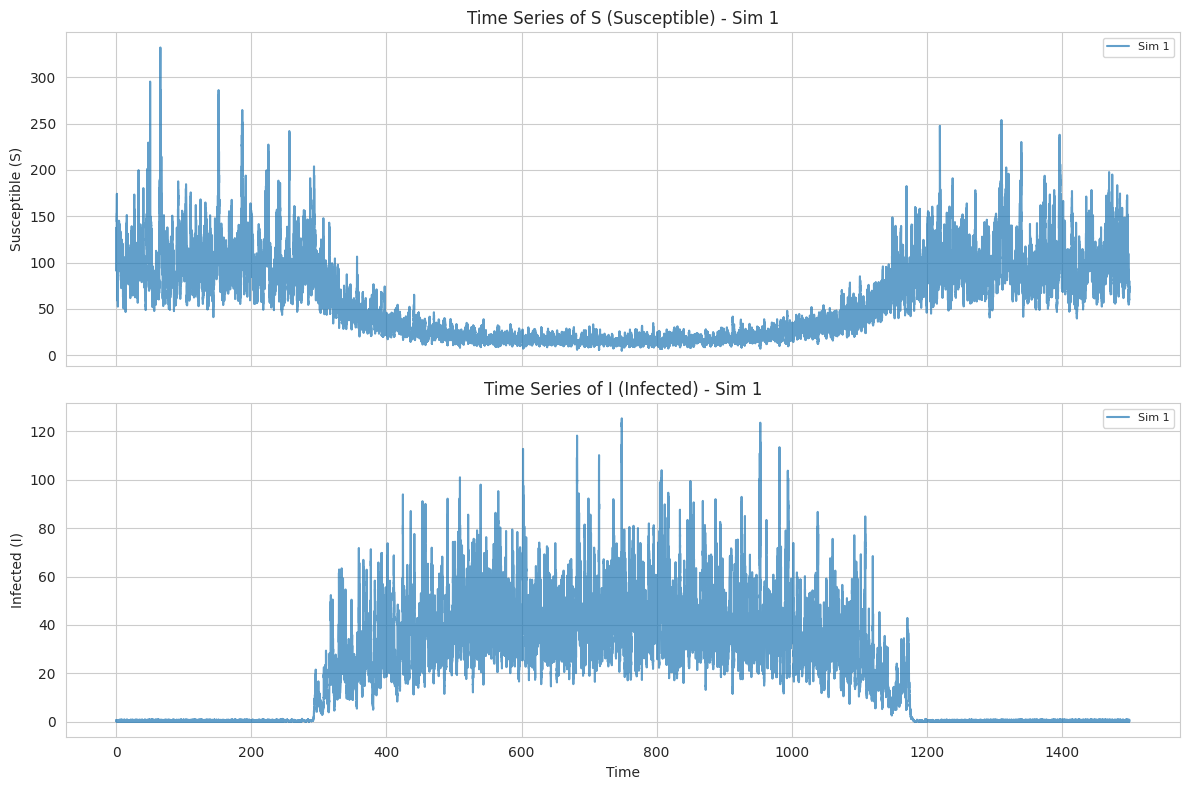

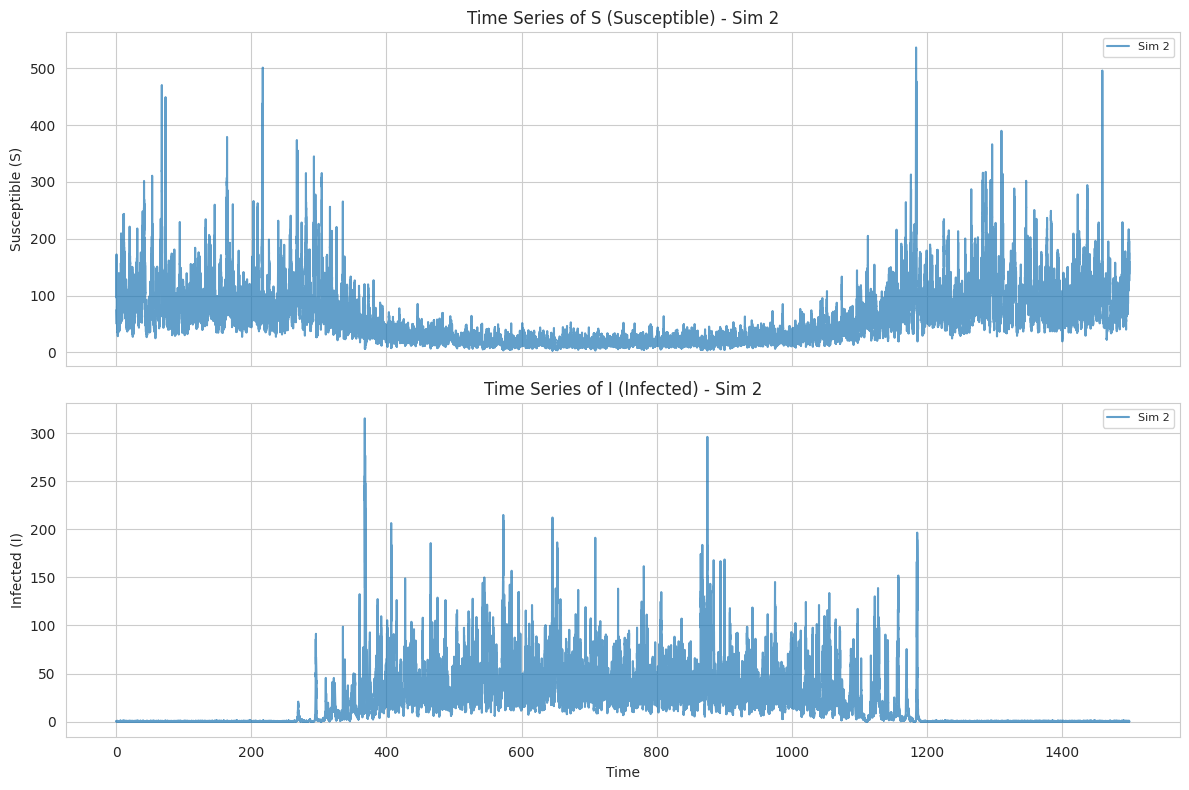

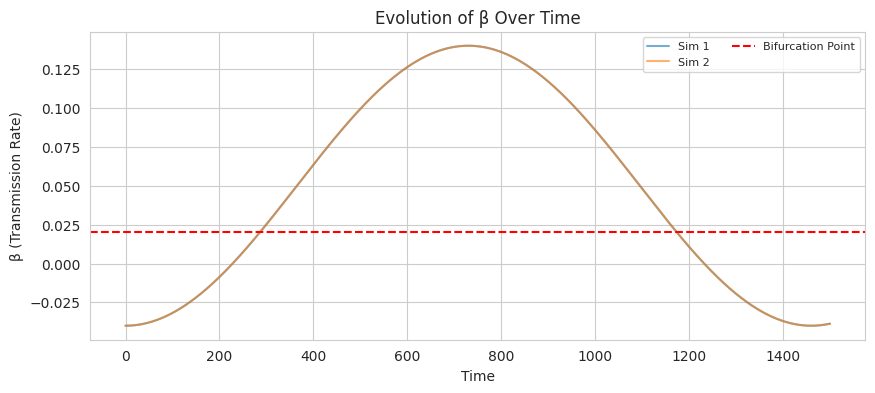

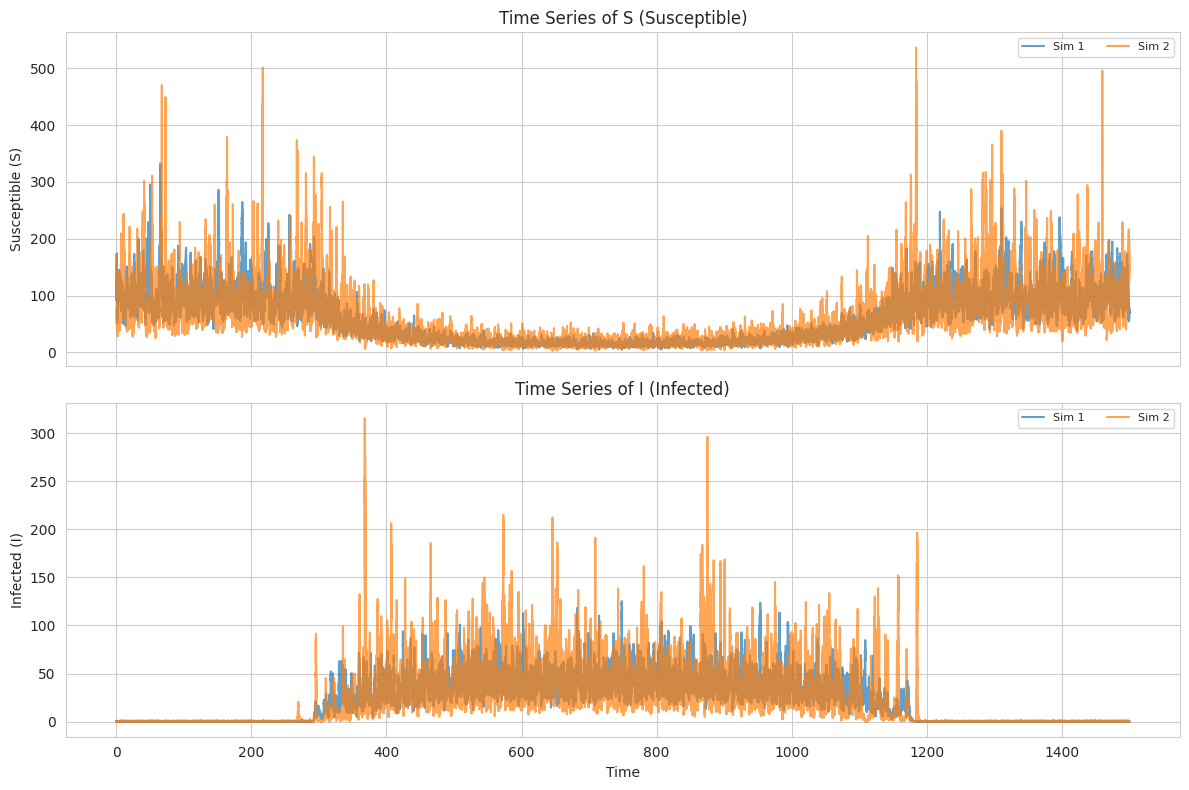

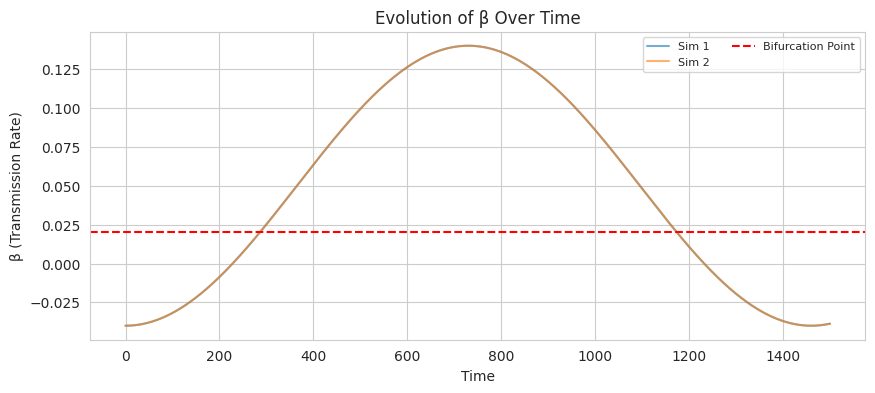

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Set Seaborn style for better visualization
sns.set_style("whitegrid")

# Plot simulation results for S (Susceptible) and I (Infected)
for i in range(numSims):
    # Create a new figure for each simulation
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Extract data for the current simulation
    ts_data = df_traj.xs(i + 1, level="tsid")

    # Plot S (Susceptible) over time
    axes[0].plot(ts_data.index, ts_data["S"], alpha=0.7, label=f"Sim {i + 1}")
    axes[0].set_ylabel("Susceptible (S)")
    axes[0].set_title(f"Time Series of S (Susceptible) - Sim {i + 1}")
    axes[0].legend(loc="upper right", fontsize=8)

    # Plot I (Infected) over time
    axes[1].plot(ts_data.index, ts_data["I"], alpha=0.7, label=f"Sim {i + 1}")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Infected (I)")
    axes[1].set_title(f"Time Series of I (Infected) - Sim {i + 1}")
    axes[1].legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

# Plot the evolution of beta over time (separate figure)
plt.figure(figsize=(10, 4))
for i in range(numSims):
    plt.plot(t, beta, alpha=0.6, label=f"Sim {i + 1}" if i < 5 else "")  # Limit labels for clarity

plt.axhline(y=betabif, color='r', linestyle='--', label="Bifurcation Point")
plt.xlabel("Time")
plt.ylabel("β (Transmission Rate)")
plt.title("Evolution of β Over Time")
plt.legend(fontsize=8, ncol=2)  # Adjust ncol for better label placement
plt.show()
# Set Seaborn style for better visualization
sns.set_style("whitegrid")

# Plot simulation results for S (Susceptible) and I (Infected)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot S (Susceptible) over time
for i in range(numSims):
    ts_data = df_traj.xs(i+1, level="tsid")  # Extract data for simulation i+1
    axes[0].plot(ts_data.index, ts_data["S"], alpha=0.7, label=f"Sim {i+1}" if i < 5 else "")  # Show only first 5 labels

axes[0].set_ylabel("Susceptible (S)")
axes[0].set_title("Time Series of S (Susceptible)")
axes[0].legend(loc="upper right", fontsize=8, ncol=2)

# Plot I (Infected) over time
for i in range(2):
    ts_data = df_traj.xs(i+1, level="tsid")
    axes[1].plot(ts_data.index, ts_data["I"], alpha=0.7, label=f"Sim {i+1}" if i < 5 else "")

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Infected (I)")
axes[1].set_title("Time Series of I (Infected)")
axes[1].legend(loc="upper right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Plot the evolution of beta over time
plt.figure(figsize=(10, 4))
for i in range(numSims):
    plt.plot(t, beta, alpha=0.6, label=f"Sim {i+1}" if i < 5 else "")

plt.axhline(y=betabif, color='r', linestyle='--', label="Bifurcation Point")
plt.xlabel("Time")
plt.ylabel("β (Transmission Rate)")
plt.title("Evolution of β Over Time")
plt.legend(fontsize=8, ncol=2)
plt.show()
